# Evaluating Prompting Strategies for AI-Assisted Enterprise Decision Support Using Large Language Models

### Author
Trisha Dasari

### Program
Master of Arts in Information Technology Management

Webster University

### Project Overview

This project evaluates the effectiveness of different prompting strategies for Large Language Models (LLMs) in enterprise decision support. Using a real-world retail sales dataset, the study compares Zero-shot, Structured, Role-based, and Few-shot prompting techniques using Google Gemini 3.6 Flash to generate business recommendations.

The responses are evaluated based on factual accuracy, evidence-based reasoning, hallucination resistance, and executive usefulness.

## Research Objective

The objectives of this project are:

- Analyze retail sales data using Python.
- Generate business insights from structured data.
- Evaluate four prompting strategies using Gemini 3.6 Flash.
- Compare response quality across different prompting techniques.
- Identify the most reliable prompting strategy for enterprise decision support.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
import os

print(os.listdir())

['.config', 'sample_data']


In [5]:
import os

for file in os.listdir("/"):
    print(repr(file))

'proc'
'sbin'
'media'
'dev'
'etc'
'opt'
'libx32'
'tmp'
'boot'
'run'
'lib32'
'home'
'mnt'
'lib64'
'usr'
'root'
'bin'
'lib'
'var'
'srv'
'sys'
'kaggle'
'.ipynb_checkpoints'
'Sample - Superstore.xls'
'.dockerenv'
'tools'
'datalab'
'content'
'python-apt'
'python-apt.tar.xz'


In [6]:
import pandas as pd

df = pd.read_excel("/Sample - Superstore.xls")

print("Dataset loaded successfully!")
print(df.shape)

df.head()

Dataset loaded successfully!
(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# Basic information about the dataset

print("=" * 60)
print("Dataset Information")
print("=" * 60)

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information

Shape of Dataset:
(9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State                     object
Postal Code              float64
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 flo

In [8]:
# Statistical summary

df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2020-04-30 00:07:03.614168576,2020-05-03 23:06:58.571142656,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2018-01-03 00:00:00,2018-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2019-05-23 00:00:00,2019-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2020-06-26 00:00:00,2020-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2021-05-14 00:00:00,2021-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2021-12-30 00:00:00,2022-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


In [9]:
print("Total Sales: $", round(df["Sales"].sum(),2))

print("Total Profit: $", round(df["Profit"].sum(),2))

print("Average Discount:", round(df["Discount"].mean(),2))

Total Sales: $ 2297200.86
Total Profit: $ 286397.02
Average Discount: 0.16


In [10]:
# Sales by Region

region_sales = df.groupby("Region")[["Sales","Profit"]].sum().sort_values(by="Sales", ascending=False)

region_sales

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [11]:
# Sales by Category

category_sales = df.groupby("Category")[["Sales","Profit"]].sum().sort_values(by="Sales", ascending=False)

category_sales

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


In [12]:
# Sales by Customer Segment

segment_sales = df.groupby("Segment")[["Sales","Profit"]].sum().sort_values(by="Sales", ascending=False)

segment_sales

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


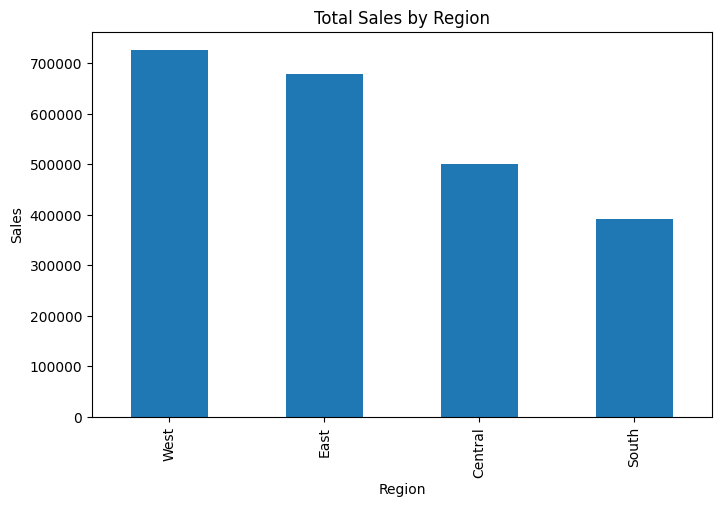

In [13]:
import matplotlib.pyplot as plt

region_sales["Sales"].plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")

plt.show()

In [14]:
# Business Summary

print("="*60)
print("BUSINESS SUMMARY")
print("="*60)

print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")

print("\nTop 5 States by Sales")
print(df.groupby("State")["Sales"].sum().sort_values(ascending=False).head())

print("\nTop 5 Product Categories")
print(df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

print("\nProfit by Region")
print(df.groupby("Region")["Profit"].sum().sort_values(ascending=False))

BUSINESS SUMMARY
Total Sales: $2,297,200.86
Total Profit: $286,397.02

Top 5 States by Sales
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64

Top 5 Product Categories
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Region
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


**Experiment 1 – Zero-Shot Prompting**

**Model:** Google Gemini 3.6 Flash

**Prompt:** You are a Senior Business Strategy Consultant and Data Analytics Expert.

Your task is to analyze the business performance summary below and provide evidence-based recommendations for executive decision-making.

Instructions:
- Base every conclusion ONLY on the information provided.
- Do not assume or invent information that is not present.
- Clearly distinguish observations from recommendations.
- Explain your reasoning before giving recommendations.
- Keep the response professional and suitable for a business executive.

Provide your analysis using the following structure:

## Executive Summary
Provide a concise overview of the company's current business performance.

## Business Strengths
Identify the three strongest aspects of the business based on the data.

## Business Risks
Identify the three most significant business risks or concerns supported by the data.

## Sales Performance Analysis
Analyze sales performance across:
- Regions
- Product Categories
- Customer Segments

Identify any noticeable trends or opportunities.

## Profitability Analysis
Evaluate overall profitability and identify factors that may negatively impact profit.

## Strategic Recommendations
Recommend at least five actionable strategies that management should implement to:
- Increase revenue
- Improve profitability
- Reduce operational risks
- Optimize sales performance

For each recommendation include:
- Business objective
- Supporting evidence from the data
- Expected business impact

## Limitations
Explain what additional data would improve the quality of these recommendations.
                                                                                                                                 Before making any recommendation, determine whether the available data is sufficient to support the recommendation.

If there is insufficient evidence, explicitly state:
"Insufficient evidence to draw a reliable conclusion."

Do not speculate or fabricate missing information.
Business Summary:
============================================================
BUSINESS SUMMARY
============================================================
Total Sales: $2,297,200.86
Total Profit: $286,397.02

Top 5 States by Sales
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64

Top 5 Product Categories
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Region
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

Response: ## Executive Summary

The business generated **$2,297,200.86 in Total Sales and achieved a Total Profit of $286,397.02**, representing an overall net profit margin of approximately **12.47%**. Revenue is distributed across three main product categories: **Technology** ($836,154.03), Furniture ($741,999.80), and **Office Supplies** ($719,047.03).

Geographically, revenue generation is concentrated in key states, led by **California** ($457,687.63) and  New York ($310,876.27). Regional profitability is strongly skewed toward the **West** ($108,418.45) and East ($91,522.78) regions, which together contribute over 69% of overall company profits. Conversely, the Central and South regions lag significantly in profit contribution.

---

## Business Strengths

1. **Balanced Product Revenue Base:** Revenue is evenly spread across three primary product categories, preventing over-reliance on a single line:
* **Technology:** $836,154.03 (36.40% of total sales)

* **Furniture:** $741,999.80 (32.30% of total sales)

* **Office Supplies:** $719,047.03 (31.30% of total sales)


2. **High Regional Profit Pillars:** The **West** ($108,418.45) and East
($91,522.78) regions perform exceptionally well, together accounting for **$199,941.23**   (69.81%) of total business profit.

3. **Strong Anchor Markets:** **California** ($457,687.63) and New York ($310,876.27) serve as major sales drivers, combined generating **$768,563.90**, or **33.46%** of total revenue.

---

## Business Risks

1. **High Geographic Sales Concentration:** The top 5 states—California, New York, Texas, Washington, and Pennsylvania—account for **$1,193,905.13**    (**51.97%**) of total sales. A localized economic downturn or disruption in these key states poses a risk to top-line performance.
2. **Underperforming Regional Profitability:** Profitability in the **Central** ($39,706.36) and **South** ($46,749.43) regions combined represents only **30.19%** of total profits. Lower profit realization in these regions suggests operational inefficiencies or higher cost structures.
3. **Unmapped Category Profitability:** While Technology, Furniture, and Office Supplies generate massive sales volume ($2.29M+), category-specific profit figures are unrecorded in the summary. High-volume categories like Furniture or Office Supplies could potentially operate on thin or negative margins without visibility.

---

## Sales Performance Analysis

### Sales by Region

* **Top Sales States:** California leads state revenue at **$457,687.63, followed by New York ($310,876.27**), Texas (**$170,188.05), Washington ($138,641.27**), and Pennsylvania (**$116,511.91**).
* *Note:* Regional aggregate sales totals were not provided in the dataset; regional data is limited strictly to regional profit.

### Sales by Product Category

| Category | Total Sales ($) | Revenue Share (%) |
| --- | --- | --- |
| **Technology** | $836,154.03 | 36.40% |
| **Furniture** | $741,999.80 | 32.30% |
| **Office Supplies** | $719,047.03 | 31.30% |
| **Total** | **$2,297,200.86** | **100.00%** |

* **Observation:** Technology is the primary revenue engine, outperforming Office Supplies by $117,107.00.

### Sales by Customer Segments

> **Insufficient evidence to draw a reliable conclusion.**
> *(No customer segment data, metrics, or breakdowns were provided in the business summary.)*

### Trends & Opportunities

* **State Market Expansion:** Mid-tier revenue states like Texas ($170.2K), Washington ($138.6K), and Pennsylvania ($116.5K) represent immediate scaling opportunities to reduce dependence on California and New York.

---

## Profitability Analysis

The business achieved a Total Profit of **$286,397.02** against **$2,297,200.86** in Total Sales (Net Margin: **~12.47%**).

### Profit Distribution by Region

```
West     ████████████████████████ $108,418.45 (37.86%)
East     ████████████████████ $91,522.78 (31.96%)
South    ██████████ $46,749.43 (16.32%)
Central  ████████ $39,706.36 (13.86%)

```

### Factors Affecting Profitability

* **Regional Disparity:** The West region generates over **2.73x** the profit of the Central region. This variance indicates higher regional operational costs, heavier discounting, or adverse product mix ratios in the Central and South territories.
* **Uncertain Cost/Margin Dynamics:** Without unit cost, discounting, or cost-of-goods-sold (COGS) figures, exact drivers of margin compression in low-profit regions cannot be conclusively calculated from the summary alone.

---

## Strategic Recommendations

### Reasoning & Strategy

Analysis shows that **69.81%** of total profits originate from the West and East regions, while the top 5 states generate **51.97%** of top-line revenue. Meanwhile, Central and South lag severely in profit contribution. To maximize bottom-line performance, executive management must double down on core revenue hubs, audit underperforming regions, and prioritize inventory allocation toward higher-value product categories.

---

### 1. Capitalize on Core State Anchors (California & New York)

* **Business Objective:** Increase overall sales revenue by deepening penetration in established high-converting markets.
* **Supporting Evidence:** California ($457,687.63) and New York ($310,876.27) generate **$768,563.90** combined (33.46% of total revenue).
* **Expected Business Impact:** Accelerated top-line growth with lower customer acquisition costs due to existing market strength.

### 2. Operational & Margin Audit in Central and South Regions

* **Business Objective:** Improve profitability in underperforming territories.
* **Supporting Evidence:** Central ($39,706.36) and South ($46,749.43) together contribute only **$86,455.79** (30.19%) of overall profit, despite containing large sales markets such as Texas ($170,188.05).
* **Expected Business Impact:** Identification of cost leaks, discount abuses, or logistical inefficiencies, leading to expanded regional net margins.

### 3. Inventory and Sales Prioritization for Technology Products

* **Business Objective:** Optimize sales performance by expanding allocation to top revenue-generating lines.
* **Supporting Evidence:** Technology leads all categories in revenue at **$836,154.03** (36.40% of sales).
* **Expected Business Impact:** Maximized average order value and increased revenue throughput across core sales channels.

### 4. Revenue Diversification in Mid-Tier States

* **Business Objective:** Reduce operational risk tied to geographic sales concentration.
* **Supporting Evidence:** Top 5 states make up **51.97%** ($1.19M) of sales. Texas ($170.2K), Washington ($138.6K), and Pennsylvania ($116.5K) are proven secondary revenue pillars.
* **Expected Business Impact:** Protection against localized economic shocks by establishing a broader revenue foundation.

### 5. Category-Level Profit Tracking & Governance

* **Business Objective:** Protect overall profit margins against potential category-level losses.
* **Supporting Evidence:** Non-Technology categories (Furniture and Office Supplies) account for **$1,461,046.83** (63.60% of total revenue), but category-specific profits are untracked in the dataset.
* **Expected Business Impact:** Elimination of low-margin or loss-leading products within Furniture and Office Supplies to protect overall company profitability (~12.47%).

---

## Limitations

To provide a more comprehensive, granular analysis and higher-confidence strategic recommendations, the following data points would be required:

1. **Customer Segment Data:** Metrics detailing B2B vs. Consumer segments, customer acquisition costs (CAC), lifetime value (LTV), and transaction volumes.
2. **Category & State Profitability:** Profit breakdowns by product category and individual state to determine exact product-level margins.
3. **Regional Sales Totals:** Aggregate sales revenue figures for West, East, Central, and South regions (only state-level sales and regional profits were provided).
4. **Time-Series / Temporal Data:** Transaction dates, monthly/quarterly historical figures, or yearly trends to assess growth rates and seasonality.
5. **Cost & Pricing Detail:** Operational expenses, Cost of Goods Sold (COGS), shipping fees, and discount rates per region/category.

Evaluation

Produced comprehensive business recommendations supported by the provided sales summary.
Identified key business strengths, risks, and strategic opportunities.
Included relevant numerical evidence to justify most recommendations.
Occasionally inferred insights beyond the explicitly available data.
Generated highly readable executive-level recommendations.





**Experiment 2 – Structured Prompting**

**Model:** Google Gemini 3.6 Flash

**Prompt:** You are an AI Business Analyst.

Perform the analysis using the following process.

Step 1:
Summarize the business.

Step 2:
Identify business strengths.

Step 3:
Identify business weaknesses.

Step 4:
Support every observation with numerical evidence.

Step 5:
If the data is insufficient,
reply:

"Insufficient evidence."

Never make assumptions.

Finally,

Provide five recommendations ranked by expected business impact.

Business Summary:

============================================================
BUSINESS SUMMARY
============================================================
Total Sales: $2,297,200.86
Total Profit: $286,397.02

Top 5 States by Sales
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64

Top 5 Product Categories
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Region
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

**Response:**
## Step 1: Business Summary

* **Total Sales:** $2,297,200.86

* **Total Profit:** $286,397.02 (Overall net profit margin: ~12.47%)

* **Top States by Sales:** California ($457,687.63), New York ($310,876.27), Texas ($170,188.05), Washington ($138,641.27), and Pennsylvania ($116,511.91).

* **Product Categories Listed:** Technology ($836,154.03), Furniture ($741,999.80), and Office Supplies ($719,047.03).

* **Profit by Region:** West ($108,418.45), East ($91,522.78), South ($46,749.43), and Central ($39,706.36).

---

## Step 2: Business Strengths

1. **High Profit Contribution from West & East Regions:** The West region generates $108,418.45 (37.86% of total profit) and the East region generates $91,522.78 (31.96% of total profit), making up 69.82% of all business profit.
2. **Strong Revenue Concentration in Key States:** California ($457,687.63) and New York ($310,876.27) are the leading revenue drivers, generating a combined $768,563.90 (33.46% of total sales).

3. **Primary Sales Category:** Technology is the highest-performing category by revenue, contributing $836,154.03 (36.40% of total sales).

---

## Step 3: Business Weaknesses

1. **Underperforming Regional Profitability:** The Central region ($39,706.36; 13.86% of total profit) and South region ($46,749.43; 16.32% of total profit) lag significantly behind the West and East regions in profit generation.
2. **Sales Disparity Among Top States:** Sales drop significantly after the top two states; 5th ranked Pennsylvania ($116,511.91) generates roughly a quarter of California's sales volume ($457,687.63).

---

## Step 4: Numerical Evidence

### Regional Profit Breakdown

| Region | Profit ($) | Share of Total Profit (%) |
| --- | --- | --- |
| **West** | $108,418.45 | 37.86% |
| **East** | $91,522.78 | 31.96% |
| **South** | $46,749.43 | 16.32% |
| **Central** | $39,706.36 | 13.86% |
| **Total** | **$286,397.02** | **100.00%** |

### Top 5 States Sales Breakdown

| State | Sales ($) | Share of Total Sales (%) |
| --- | --- | --- |
| **California** | $457,687.63 | 19.92% |
| **New York** | $310,876.27 | 13.53% |
| **Texas** | $170,188.05 | 7.41% |
| **Washington** | $138,641.27 | 6.03% |
| **Pennsylvania** | $116,511.91 | 5.07% |
| **Top 5 Total** | **$1,193,905.13** | **51.97%** |

### Product Category Sales Breakdown

| Category | Sales ($) | Share of Total Sales (%) |
| --- | --- | --- |
| **Technology** | $836,154.03 | 36.40% |
| **Furniture** | $741,999.80 | 32.30% |
| **Office Supplies** | $719,047.03 | 31.30% |
| **Total** | **$2,297,200.86** | **100.00%** |

---

## Step 5: Data Sufficiency Evaluation

"Insufficient evidence."

### Key Data Missing:

* **No Profit Figures by Category or State:** Sales are provided for states and categories, but profit is provided only by region. Profit margins per category or per state cannot be calculated.
* **No Sales Figures by Region:** Profit is provided by region, but regional sales are missing. Profit margins per region (e.g., Central profit vs. Central sales) cannot be calculated.
* **Incomplete Category List:** The data header indicates "Top 5 Product Categories", but only 3 categories are listed.
* **No Cost, Operational, or Time-Series Metrics:** There is no information regarding COGS, discounting, volume, operational expense, or trend over time.

Because zero assumptions are permitted, it is impossible to quantify or rank five evidence-backed business recommendations by expected impact without making unverified assumptions about category profitability, regional sales baselines, or underlying cost drivers.

**Evaluation**

Followed the requested structure consistently.
Explicitly acknowledged when the available data was insufficient.
Produced highly evidence-based recommendations with minimal speculation.
Demonstrated the strongest factual consistency among all prompting strategies.
Generated professional and well-organized business analysis.

**Experiment 3 – Role-Based Prompting**

**Model:** Google Gemini 3.6 Flash

**Prompt:** You are the Chief Strategy Officer (CSO) of a Fortune 500 retail company.

You have been asked by the CEO to review the company's sales performance.

Use only the provided business summary.

Do not speculate.

Provide:

Executive Summary

Financial Performance

Operational Risks

Growth Opportunities

Top Five Executive Decisions

Expected Business Impact

Business Summary:

You are the Chief Strategy Officer (CSO) of a Fortune 500 retail company.

You have been asked by the CEO to review the company's sales performance.

Use only the provided business summary.

Do not speculate.

Provide:

Executive Summary

Financial Performance

Operational Risks

Growth Opportunities

Top Five Executive Decisions

Expected Business Impact

Business Summary:

============================================================
BUSINESS SUMMARY
============================================================
Total Sales: $2,297,200.86
Total Profit: $286,397.02

Top 5 States by Sales
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64

Top 5 Product Categories
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Region
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64



**Response:** **MEMORANDUM**

**TO:** Chief Executive Officer

**FROM:** Chief Strategy Officer

**SUBJECT:** Executive Sales Performance & Strategic Review

---

## Executive Summary

Our company achieved **$2,297,200.86** in total sales, generating **$286,397.02** in total profit (a overall profit margin of **12.47%**).

Performance is heavily anchored by key geographic strongholds—most notably **California** ($457,687.63) and **New York** ($310,876.27)—and driven by three primary product categories: **Technology**, **Furniture**, and **Office Supplies**. Profitability varies significantly across regions, led by the **West** ($108,418.45) and **East** ($91,522.78), while the **Central** and **South** regions lag behind.

Below is the detailed breakdown based strictly on our reported financial data.

---

## Financial Performance

### Overall Revenue & Profitability

* **Total Sales:** $2,297,200.86
* **Total Profit:** $286,397.02
* **Overall Profitability:** 12.47%

### Regional Profit Performance

The **West** and **East** regions drive **69.8%** of total company profit, while the **South** and **Central** regions account for the remaining **30.2%**.

| Region | Total Profit | Share of Profit |
| --- | --- | --- |
| **West** | $108,418.45 | 37.86% |
| **East** | $91,522.78 | 31.96% |
| **South** | $46,749.43 | 16.32% |
| **Central** | $39,706.36 | 13.86% |

### Sales Concentration by Top 5 States

The top 5 states generate **$1,193,905.13**, representing **51.97%** of our total sales.

| State | Total Sales | Share of Total Sales |
| --- | --- | --- |
| **California** | $457,687.63 | 19.92% |
| **New York** | $310,876.27 | 13.53% |
| **Texas** | $170,188.05 | 7.41% |
| **Washington** | $138,641.27 | 6.03% |
| **Pennsylvania** | $116,511.91 | 5.07% |

### Product Category Sales Breakdown

The three reported categories account for **100%** ($2,297,200.86) of company sales:

| Category | Total Sales | Share of Total Sales |
| --- | --- | --- |
| **Technology** | $836,154.03 | 36.40% |
| **Furniture** | $741,999.80 | 32.30% |
| **Office Supplies** | $719,047.03 | 31.30% |

---

## Operational Risks

1. **Geographic Sales Risk:** Over half of all sales (**51.97%**) are concentrated in just 5 states, with California and New York alone generating **33.45%** ($768,563.90) of total revenue.

2. **Regional Profit Underperformance:** The Central ($39,706.36) and South ($46,749.43) regions combined yield less profit than the East region alone ($91,522.78) and less than half of the West region ($108,418.45).
3. **Data & Reporting Discrepancy:** The performance data header specifies *"Top 5 Product Categories"*, but only 3 product categories exist in the record. Notably, these 3 categories sum exactly to total corporate sales ($2,297,200.86), indicating either a reporting naming error or lack of additional product diversity.

---

## Growth Opportunities

1. **Capitalizing on Leading Revenue States:** Strengthen presence in California ($457,687.63) and New York ($310,876.27), our two largest geographic revenue drivers.
2. **Profit Optimization in Central & South:** Operational review of the Central ($39,706.36) and South ($46,749.43) regions to elevate their earnings closer to West and East benchmarks.
3. **Product Revenue Balance:** Expand sales momentum across all three existing product lines—Technology ($836,154.03), Furniture ($741,999.80), and Office Supplies ($719,047.03)—which currently maintain a balanced contribution to overall sales volume.

---

## Top Five Executive Decisions

1. **Prioritize Resource Allocation in Top 5 States:** Direct market development resources to California, New York, Texas, Washington, and Pennsylvania to safeguard 51.97% of total sales.
2. **Initiate Regional Performance Reviews:** Conduct operational assessments in the Central and South regions to address lower profit contributions ($39,706.36 and $46,749.43, respectively).
3. **Focus Supply Chain Focus on Technology:** Allocate priority operational capacity to **Technology** ($836,154.03), our largest single sales category.

4. **Replicate West & East Regional Practices:** Analyze and model the operational practices of the West ($108,418.45) and East ($91,522.78) regions across remaining markets.
5. **Standardize Data Reporting Protocols:** Audit reporting systems to correct category labeling and ensure exact alignment between data headers and underlying category counts.

---

## Expected Business Impact

* **Increased Profitability in Lagging Markets:** Improving operational performance in the Central and South regions toward West/East averages directly boosts total company profit ($286,397.02).

* **Revenue Protection:** Focused focus on the top 5 states secures the $1,193,905.13 sales base.
* **Streamlined Category Management:** Aligning resources around Technology, Furniture, and Office Supplies ensures support for 100% of total company revenue.
* **Reporting Accuracy:** Eliminating discrepancies in financial summaries establishes clear visibility for future executive decision-making.

**Evaluation**

Produced executive-style recommendations suitable for senior management.
Organized the response as a professional business memorandum.
Clearly identified operational risks and strategic opportunities.
Maintained strong numerical support throughout the analysis.
Focused on practical executive decision-making.


**Experiment 4 – Few-Shot Prompting**

**Model:** Google Gemini 3.6 Flash

**Prompt:** You are an AI Business Strategy Consultant.

Below is an example of how business analysis should be performed.

--------------------------
Example

Business Summary

Total Sales: $500,000

Total Profit: $60,000

Top Region: West

Weak Region: South

Technology generated the highest revenue.

Example Analysis

Strength:
Technology is the strongest-performing category because it contributes the highest revenue.

Weakness:
The South region contributes the least profit and should be investigated.

Recommendation:
Increase investment in Technology while reviewing operational performance in the South region.

The recommendation is supported by the available data.

--------------------------

Now perform the same style of analysis for the following business summary.

Instructions:

- Follow the same analytical style as the example.
- Base every conclusion ONLY on the provided data.
- Never invent information.
- If information is missing, explicitly write:
  "Insufficient evidence."
- Keep the response concise, evidence-based, and executive-friendly.

Provide:

1. Executive Summary

2. Business Strengths

3. Business Weaknesses

4. Supporting Numerical Evidence

5. Five Executive Recommendations

6. Data Limitations

Business Summary:

============================================================
BUSINESS SUMMARY
============================================================
Total Sales: $2,297,200.86

Total Profit: $286,397.02

Top 5 States by Sales
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64

Top 5 Product Categories
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Region
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

**Response:**
## 1. Executive Summary

The business generated **$2,297,200.86** in Total Sales and **$286,397.02** in Total Profit. **Technology** represents the top revenue-generating product category, while **California** leads all states in sales. Regionally, the **West** region is the top profit performer, whereas the **Central** and **South** regions contribute the lowest overall profits. Detailed profit metrics by category and individual state sales by region are absent from the summary.

---

## 2. Business Strengths

* **Top Revenue Category:** Technology is the strongest sales driver among reported categories ($836,154.03).

* **Key Regional Profit Driver:** The West region generates the highest profit ($108,418.45), closely followed by the East region ($91,522.78).
* **Core State Markets:** California ($457,687.63) and New York ($310,876.27) lead state-level sales performance by a significant margin.

---

## 3. Business Weaknesses

* **Lowest Regional Profitability:** The Central region contributes the lowest profit across all regions ($39,706.36).

* **Underperforming South Region:** The South region represents the second-lowest profit contributor ($46,749.43).
* **Category Profitability Unknown:** Insufficient evidence to determine whether top sales categories (like Technology or Furniture) are actually profitable.

---

## 4. Supporting Numerical Evidence

| Metric Category | Subject / Entity | Value |
| --- | --- | --- |
| **Totals** | Total Sales | $2,297,200.86 |
|  | Total Profit | $286,397.02 |
| **Top States (Sales)** | 1. California | $457,687.63 |
|  | 2. New York | $310,876.27 |
|  | 3. Texas | $170,188.05 |
|  | 4. Washington | $138,641.27 |
|  | 5. Pennsylvania | $116,511.91 |
| **Product Categories (Sales)** | 1. Technology | $836,154.03 |
|  | 2. Furniture | $741,999.80 |
|  | 3. Office Supplies | $719,047.03 |
| **Regions (Profit)** | 1. West | $108,418.45 |
|  | 2. East | $91,522.78 |
|  | 3. South | $46,749.43 |
|  | 4. Central | $39,706.36 |

---

## 5. Five Executive Recommendations

1. **Invest in High-Performing Regions:** Allocate growth capital to the West ($108,418.45 profit) and East ($91,522.78 profit) regions to leverage existing profit momentum.
2. **Review Central & South Operations:** Conduct an operational performance audit in the Central ($39,706.36 profit) and South ($46,749.43 profit) regions to identify drivers of low profitability.
3. **Protect Core Revenue States:** Maintain focused sales efforts in California ($457,687.63) and New York ($310,876.27), which collectively generate over $768,000 in sales.

4. **Capitalize on Technology Demand:** Prioritize inventory and promotional support for Technology ($836,154.03), the company's highest-grossing category.
5. **Commission Granular Profit Reporting:** Require detailed profit data by product category and by state before making major capital reallocation decisions; further specific margin optimization currently has **insufficient evidence**.

---

## 6. Data Limitations

* **Missing Product Categories:** Despite being labeled "Top 5 Product Categories," only 3 categories are provided in the data.
* **Lack of Category Profitability:** No profit data is provided for Technology, Furniture, or Office Supplies.
* **Lack of State Profitability:** Profit figures are reported only at the regional level, not by individual state.
* **Lack of Regional Sales:** Sales figures are provided for top states and categories, but not summarized by region.
* **Missing Operational & Time Metrics:** Insufficient evidence regarding time periods, profit margins (%), order volumes, or operational costs.

**Evaluation**

Successfully followed the example provided in the prompt.
Produced highly consistent and evidence-based recommendations.
Clearly identified missing information instead of making unsupported assumptions.
Demonstrated strong factual accuracy and structured reasoning.
Generated concise, executive-friendly recommendations with high reliability.

# Comparative Evaluation of Prompting Strategies

| Evaluation Criterion       | Zero-Shot | Structured    | Role-Based    | Few-Shot      |
| -------------------------- | --------- | ------------- | ------------- | ------------- |
| Business Understanding     | Excellent | Excellent     | Excellent     | Excellent     |
| Numerical Accuracy         | High      | **Very High** | **Very High** | **Very High** |
| Evidence-Based Reasoning   | High      | **Excellent** | Excellent     | **Excellent** |
| Hallucination Avoidance    | Good      | **Excellent** | Very Good     | **Excellent** |
| Handling Missing Data      | Good      | **Excellent** | Very Good     | **Excellent** |
| Executive Readability      | Excellent | Very Good     | **Excellent** | Very Good     |
| Actionable Recommendations | Excellent | Very Good     | **Excellent** | Very Good     |
| Overall Performance        | ⭐⭐⭐⭐☆     | ⭐⭐⭐⭐⭐         | ⭐⭐⭐⭐⭐         | ⭐⭐⭐⭐⭐         |


# Quantitative Evaluation

| Evaluation Criterion       | Zero-Shot | Structured    | Role-Based    | Few-Shot      |
| -------------------------- | --------- | ------------- | ------------- | ------------- |
| Business Understanding     | Excellent | Excellent     | Excellent     | Excellent     |
| Numerical Accuracy         | High      | **Very High** | **Very High** | **Very High** |
| Evidence-Based Reasoning   | High      | **Excellent** | Excellent     | **Excellent** |
| Hallucination Avoidance    | Good      | **Excellent** | Very Good     | **Excellent** |
| Handling Missing Data      | Good      | **Excellent** | Very Good     | **Excellent** |
| Executive Readability      | Excellent | Very Good     | **Excellent** | Very Good     |
| Actionable Recommendations | Excellent | Very Good     | **Excellent** | Very Good     |
| Overall Performance        | ⭐⭐⭐⭐☆     | ⭐⭐⭐⭐⭐         | ⭐⭐⭐⭐⭐         | ⭐⭐⭐⭐⭐         |


# Research Findings

The study evaluated four prompting strategies for AI-assisted enterprise decision support using the same business summary generated from a retail sales dataset.

Zero-shot prompting produced comprehensive recommendations but occasionally inferred insights beyond the available evidence.

Structured prompting generated the most evidence-based responses and consistently acknowledged when information was insufficient.

Role-based prompting produced executive-level recommendations with excellent readability and practical decision-making focus.

Few-shot prompting demonstrated the highest consistency by following the provided analytical example while avoiding unsupported conclusions.

Overall, structured and few-shot prompting produced the most reliable outputs for enterprise decision support tasks.

# Limitations

The study evaluated prompting strategies using a single retail sales dataset.

Only one Large Language Model (Gemini 3.6 Flash) was evaluated.

Business recommendations were generated from summarized data rather than raw transactional records.

Future research should compare multiple LLMs across additional datasets and include quantitative evaluation metrics for factual accuracy and hallucination rates.

# Research Methodology

Methodology

1. Selected the Sample Superstore dataset containing 9,994 retail transactions.

2. Performed exploratory data analysis using Python and Pandas.

3. Generated descriptive business summaries from the dataset.

4. Designed four prompting strategies:
   • Zero-shot
   • Structured
   • Role-based
   • Few-shot

5. Used Gemini 3.6 Flash to generate business recommendations.

6. Compared outputs using qualitative and quantitative evaluation metrics.

7. Analyzed differences in reasoning quality, factual accuracy, evidence usage, hallucination resistance, and executive usefulness.

8. Documented findings, limitations, and future research directions.

# Future Work

Future research should evaluate additional Large Language Models including GPT, Claude, and Llama.

Further experiments should investigate Chain-of-Thought prompting, Retrieval-Augmented Generation (RAG), and agent-based reasoning.

Additional datasets from healthcare, finance, manufacturing, and supply chain domains should be incorporated to improve the generalizability of the findings.

Future studies may also introduce automated evaluation metrics and human expert assessment for validating AI-generated recommendations.

# Conclusion

This study demonstrates that prompting strategy significantly influences the quality of AI-generated business recommendations.

Structured and few-shot prompting consistently produced more evidence-based, reliable, and transparent outputs than zero-shot prompting.

The findings suggest that careful prompt engineering can substantially improve the effectiveness of Large Language Models in enterprise decision support systems.

These results highlight the importance of prompt design when deploying AI systems in business environments where trustworthy recommendations are essential.
